In [1]:
import time

import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d.axes3d as p3  # noqa: F401
import numpy as np
from matplotlib import offsetbox
from sklearn.datasets import load_digits, make_s_curve
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

import datafold.dynfold as dfold
import datafold.pcfold as pfold
from datafold.dynfold import LocalRegressionSelection
from datafold.utils.plot import plot_pairwise_eigenvector

import src.model_systems as model_systems
import src.helpers as helpers
import src.potentials as potentials
import src.diffusion_map as diffusion_map

/Users/shashanksule/miniforge3/envs/3pe/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/shashanksule/miniforge3/envs/3pe/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


# Get digits

In [2]:
digits = load_digits(n_class=6)
X = digits.data
y = digits.target
images = digits.images

Tune epsilon:

In [3]:
X_pcm = pfold.PCManifold(X)
X_pcm.optimize_parameters(result_scaling=2, k=200)

(102.07840124139877, 565.6685626789855)

# Compute Roseland embedding

In [4]:
rose = dfold.Roseland(
        n_svdtriplet=6,
        kernel=pfold.GaussianKernel(
            epsilon=X_pcm.kernel.epsilon, distance=dict(cut_off=X_pcm.cut_off)
        ),
        random_state=42,
    )
rose = rose.fit(X_pcm)
svdvecs, svdvals = rose.svdvec_left_, rose.svdvalues_ 

Get landmarks:

In [5]:
subsample_inds = []
for i in range(rose.landmarks_.shape[0]):
    row_index = np.where(np.all(X == rose.landmarks_[i], axis=1))
    subsample_inds.append(row_index[0][0])

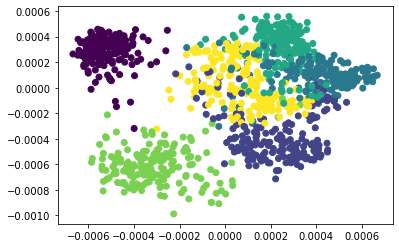

In [6]:
plt.scatter(svdvecs[:,1], svdvecs[:,2], c=y)

# Neumann map

In [7]:
boolean_vector = np.ones(X_pcm.shape[0], dtype=bool)
boolean_vector[subsample_inds] = False
nmap = diffusion_map.NeumannMap(alpha=0.0,epsilon=X_pcm.kernel.epsilon,num_evecs=15, delta=0.5, n_neigh=200)
nmap.construct_generator(X_pcm.T, boolean_vector)
L_nmap = nmap.get_generator()
nmap, nevecs3, nevals3 = nmap._construct_diffusion_coords(L_nmap)

computing eigvec matrix


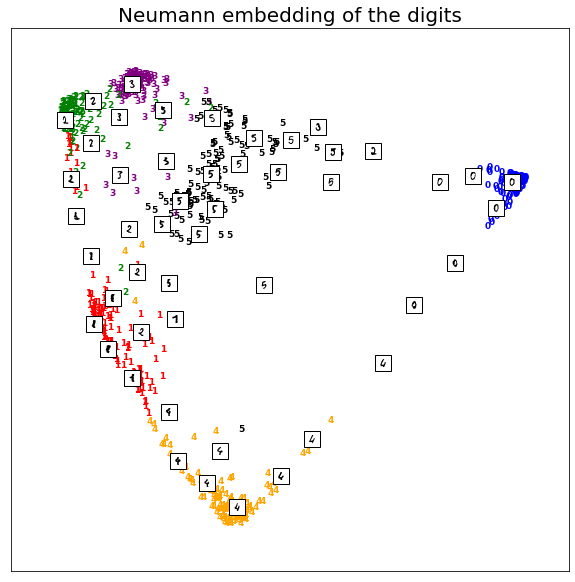

In [8]:
helpers.plot_embedding(
    nmap[:,:2],
    y[boolean_vector],
    images[boolean_vector],
    fname = None,
    title="Neumann embedding of the digits",
)

# Generate metrics

In [13]:
from sklearn.cluster import KMeans

In [14]:
kmeans_roseland = KMeans(n_clusters=6, random_state=0, max_iter=100000, n_init="auto").fit(svdvecs[boolean_vector,1:3])
kmeans_Nmap = KMeans(n_clusters=6, random_state=0, max_iter=100000, n_init="auto").fit(nmap[:,:2])
true_labels = y[boolean_vector]

In [30]:
def cost_fn(labels, true_labels, a,b): 
    # a is the computed label, b is the true label
    labels_at_true = labels[true_labels == b]
    labels_at_true[labels_at_true == a] = b
    return np.sum(labels_at_true == true_labels[true_labels == b])

def cost_matrix(labels, true_labels): 
    cost_matrix = np.zeros((6,6))
    for i in range(6): 
        for j in range(6): 
            cost_matrix[i,j] = cost_fn(labels, true_labels, i,j)
    return cost_matrix

In [49]:
cost_matrix_nmap = cost_matrix(kmeans_Nmap.labels_, true_labels)
cost_matrix_roseland = cost_matrix(kmeans_roseland.labels_, true_labels)

In [43]:
from scipy.sparse.csgraph import maximum_bipartite_matching
from scipy.sparse.csgraph import min_weight_full_bipartite_matching
from scipy.sparse import csr_matrix

In [50]:
permutation_nmap = min_weight_full_bipartite_matching(csr_matrix(-cost_matrix_nmap-1))[1]
permutation_roseland = min_weight_full_bipartite_matching(csr_matrix(-cost_matrix_roseland-1))[1]

# permutation_roseland = [5, 4, 0, 2, 1, 3]
# permutation_nmap = [5, 0, 4, 2, 1, 3]

permuted_labels_roseland, permuted_labels_nmap = [], []
for idx in range(len(true_labels)): 
    permuted_labels_roseland.append(permutation_roseland[kmeans_roseland.labels_[idx]])
    permuted_labels_nmap.append(permutation_nmap[kmeans_Nmap.labels_[idx]])

In [104]:
np.savez('UCI_digits_landmarks.npz', boolean_vector=boolean_vector, X=X, labels=y, knn=200, epsilon=X_pcm.kernel.epsilon, \
        permutation_roseland=permutation_roseland, permutation_nmap=permutation_nmap)

In [107]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, normalized_mutual_info_score
acc_roseland = balanced_accuracy_score(true_labels, permuted_labels_roseland)
acc_Nmap = balanced_accuracy_score(true_labels, permuted_labels_nmap)
nmi_roseland = normalized_mutual_info_score(true_labels, permuted_labels_roseland)
nmi_Nmap = normalized_mutual_info_score(true_labels, permuted_labels_nmap)

In [109]:
nmi_roseland, nmi_Nmap, acc_roseland, acc_Nmap

(0.7063791274809775,
 0.8495285299151913,
 0.8403975254288597,
 0.9315333146290349)